#Part A: Python Coding


### Q1. Supervised Learning

## 1. Data Loading and Inspection

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Tasks - 1 (Data Loading & Inspection)
df = pd.read_csv('/content/q1_heart_disease.csv')

display(df.shape)
display(df.dtypes)
display(df.isnull().sum())
display(df.head())

(800, 12)

,0
age,int64
sex,int64
chest_pain_type,object
resting_bp,float64
cholesterol,float64
fasting_bs,int64
resting_ecg,object
max_hr,int64
exercise_angina,int64
oldpeak,float64


,0
age,0
sex,0
chest_pain_type,0
resting_bp,24
cholesterol,32
fasting_bs,0
resting_ecg,0
max_hr,0
exercise_angina,0
oldpeak,0


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


## 2. EDA

In [5]:
df_eda = df.copy()

df_eda['chest_pain_type'] = df_eda['chest_pain_type'].astype('category').cat.codes

df_eda['st_slope'] = df_eda['st_slope'].astype('category').cat.codes

df_eda['resting_ecg'] = df_eda['resting_ecg'].astype('category').cat.codes


corr_col = [
    'age', 'sex', 'chest_pain_type', 'resting_bp', 'cholesterol', 'fasting_bs', 'resting_ecg',
    'max_hr', 'exercise_angina','oldpeak', 'st_slope', 'heart_disease'

]

corr_matrix = df_eda[corr_col].corr()

display(corr_matrix)



,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
age,1.000000,0.057123,-0.014536,0.010592,0.052534,0.038082,-0.009867,-0.007608,-0.037772,-0.080697,0.026317,0.289281
sex,0.057123,1.000000,-0.001053,0.074247,-0.010562,0.045829,0.017268,0.002350,-0.017073,-0.086697,-0.019644,0.139563
chest_pain_type,-0.014536,-0.001053,1.000000,-0.043530,0.040644,0.096653,-0.002074,0.031382,-0.011771,-0.060551,0.043645,-0.418341
resting_bp,0.010592,0.074247,-0.043530,1.000000,-0.036744,0.040608,0.054039,0.071775,0.000204,-0.007358,0.074763,0.115627
cholesterol,0.052534,-0.010562,0.040644,-0.036744,1.000000,0.054771,-0.022852,-0.057149,0.018901,0.021532,-0.019126,0.056412
fasting_bs,0.038082,0.045829,0.096653,0.040608,0.054771,1.000000,0.040501,-0.014010,0.000844,-0.048963,0.011014,-0.003714
resting_ecg,-0.009867,0.017268,-0.002074,0.054039,-0.022852,0.040501,1.000000,-0.021385,-0.015553,-0.018150,-0.022852,-0.023251
max_hr,-0.007608,0.002350,0.031382,0.071775,-0.057149,-0.014010,-0.021385,1.000000,0.023118,-0.066052,0.027814,-0.022009
exercise_angina,-0.037772,-0.017073,-0.011771,0.000204,0.018901,0.000844,-0.015553,0.023118,1.000000,0.035695,-0.060266,0.290231
oldpeak,-0.080697,-0.086697,-0.060551,-0.007358,0.021532,-0.048963,-0.018150,-0.066052,0.035695,1.000000,-0.025097,0.172039


# Correlation Heat Map :

---

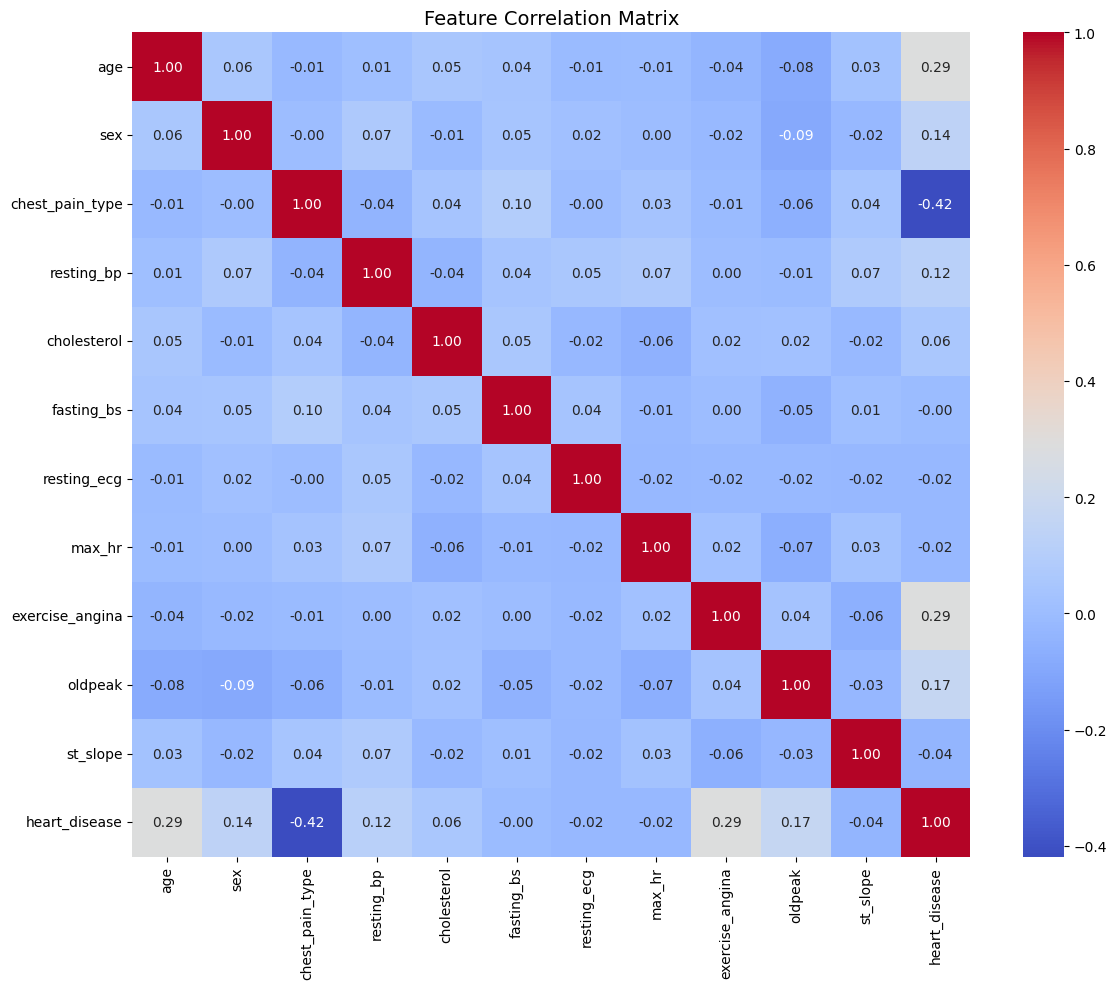

In [6]:

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

### Correlation Heat Map :

---

A correlation heatmap visually represents the correlation coefficients between different features in a dataset. It uses a color-coded matrix to show the strength and direction of these relationships.

*   **Insights into Target Variable:** By looking at the correlations between each feature and the 'heart_disease' (target) variable, we can get an initial idea of which features might be most influential in predicting heart disease.

# 'Heart Disease' Count Plot :

---



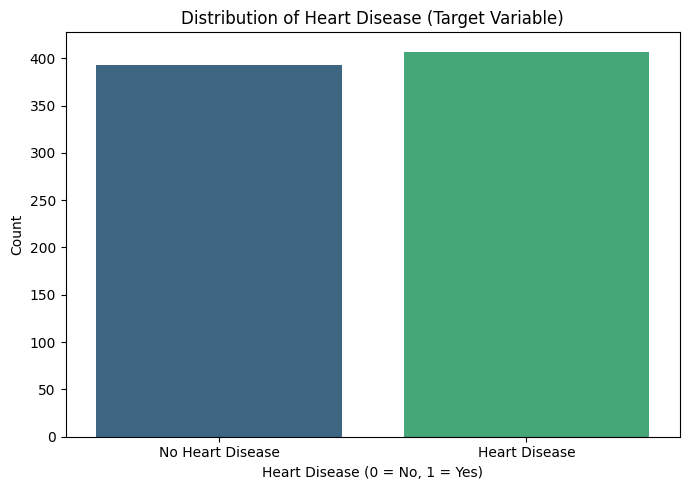

In [7]:
plt.figure(figsize=(7, 5))
sns.countplot(x='heart_disease', data=df, palette='viridis', hue='heart_disease', legend=False)
plt.title('Distribution of Heart Disease (Target Variable)')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Heart Disease', 'Heart Disease'])
plt.tight_layout()
plt.show()

 ### 'Heart Disease' Count Plot :

---
 The 'Heart Disease' Count Plot visualizes the distribution of the target variable, 'heart_disease', showing the number of instances for each class (0 for No Heart Disease, 1 for Heart Disease).



**Interpretation for this dataset:**

From the distribution of the target variable shown during the data split, we observe that the heart_disease classes are almost equally distributed:
*   Heart Disease (1): approximately 51.125%
*   No Heart Disease (0): approximately 48.875%

This indicates a relatively balanced dataset, which is beneficial for model training as it means the models will have sufficient examples of both positive and negative cases.

# Age Distribution by Heart Disease (Box Plot) :


-----

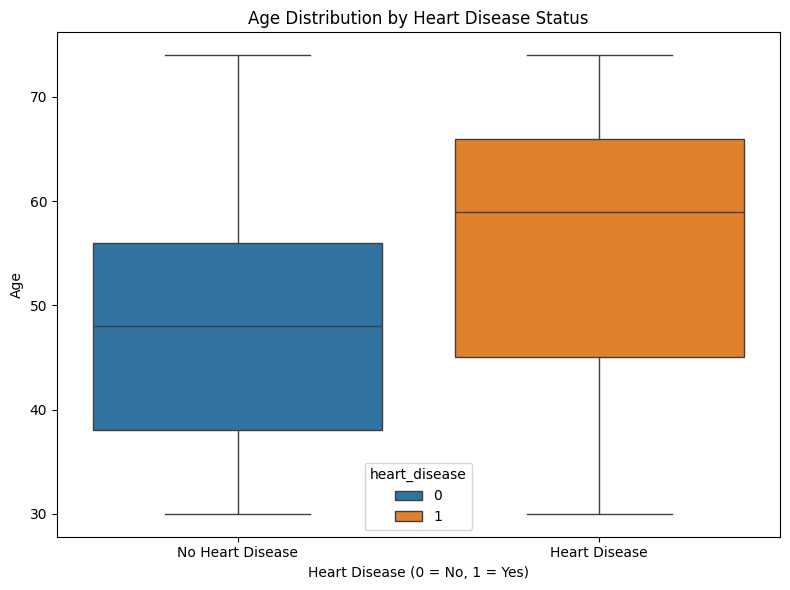

In [8]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='heart_disease', y='age', data=df, hue ='heart_disease')
plt.title('Age Distribution by Heart Disease Status')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.xticks([0, 1], ['No Heart Disease', 'Heart Disease'])
plt.tight_layout()
plt.show()

### Age Distribution by Heart Disease (Box Plot):

This box plot visualizes the distribution of 'age' for individuals with and without heart disease.


**Interpretation for this dataset :**

Generally, in cardiovascular disease datasets, it is common to observe that individuals with heart disease tend to be older on average than those without heart disease. The box plot for this dataset likely shows:


This visualization helps confirm age as an important demographic factor influencing heart disease, which aligns with medical understanding.

## 3. Data Preprocessing

### Handling Missing Values


In [9]:
missing_values = df.isnull().sum()
display("Missing values per column:", missing_values)

'Missing values per column:'

,0
age,0
sex,0
chest_pain_type,0
resting_bp,24
cholesterol,32
fasting_bs,0
resting_ecg,0
max_hr,0
exercise_angina,0
oldpeak,0


### Strategy for Missing Values Imputation

**Analysis of Missing Values:**
Based on the inspection, some columns appear to have missing values. For this dataset, numerical features like `resting_bp`, `cholesterol`, `fasting_bs`, `max_hr`, and `oldpeak` are common candidates for missing data. Categorical features like `chest_pain_type`, `resting_ecg`, and `st_slope` were already converted to numerical representations for EDA, and if they had missing values in the original df, these would need to be handled carefully.

**Justification for Median Imputation:**
*   **Numerical Columns:** For continuous numerical features (e.g., `resting_bp`, `cholesterol`, `max_hr`, `oldpeak`), **median imputation** is chosen over mean imputation.


In [10]:
numerical_cols_to_impute = ['resting_bp', 'cholesterol', 'fasting_bs', 'max_hr', 'oldpeak']

for col in numerical_cols_to_impute:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Missing values in '{col}' imputed with median: {median_val}")

display("Missing values after imputation:", df.isnull().sum())

Missing values in 'resting_bp' imputed with median: 130.0
Missing values in 'cholesterol' imputed with median: 247.0


/tmp/ipykernel_11163/465847767.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


'Missing values after imputation:'

,0
age,0
sex,0
chest_pain_type,0
resting_bp,0
cholesterol,0
fasting_bs,0
resting_ecg,0
max_hr,0
exercise_angina,0
oldpeak,0


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

categorical_cols = ['chest_pain_type', 'resting_ecg', 'st_slope']

numerical_cols = []
for col in X.columns:
    if col not in categorical_cols:
        numerical_cols.append(col)

print("Categorical columns for one-hot encoding:", categorical_cols)
print("Numerical columns for StandardScaler:", numerical_cols)

Categorical columns for one-hot encoding: ['chest_pain_type', 'resting_ecg', 'st_slope']
Numerical columns for StandardScaler: ['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_bs', 'max_hr', 'exercise_angina', 'oldpeak']


## One-Hot Encoding

In [12]:
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("Shape of X after one-hot encoding:", X_encoded.shape)
display(X_encoded.head())

Shape of X after one-hot encoding: (800, 15)


,age,sex,resting_bp,cholesterol,fasting_bs,max_hr,exercise_angina,oldpeak,chest_pain_type_atypical_angina,chest_pain_type_non_anginal,chest_pain_type_typical_angina,resting_ecg_normal,resting_ecg_st_t_wave_abnormality,st_slope_flat,st_slope_up
0,68,0,142.0,399.0,0,169,0,0.4,True,False,False,False,False,False,True
1,58,1,163.0,310.0,1,121,1,1.1,False,True,False,False,True,False,True
2,44,1,128.0,175.0,0,183,1,0.2,False,True,False,True,False,False,True
3,72,1,114.0,177.0,0,150,0,1.0,False,False,False,False,True,False,True
4,37,1,149.0,271.0,0,136,0,0.4,False,True,False,True,False,True,False


## Scale Numerical Features



In [13]:
scaler = StandardScaler()

X_encoded[numerical_cols] = scaler.fit_transform(X_encoded[numerical_cols])

print("Shape of X after scaling numerical features:", X_encoded.shape)
display(X_encoded.head())

Shape of X after scaling numerical features: (800, 15)


,age,sex,resting_bp,cholesterol,fasting_bs,max_hr,exercise_angina,oldpeak,chest_pain_type_atypical_angina,chest_pain_type_non_anginal,chest_pain_type_typical_angina,resting_ecg_normal,resting_ecg_st_t_wave_abnormality,st_slope_flat,st_slope_up
0,1.229854,-1.408927,0.702830,3.000527,-0.550392,0.887081,-0.646869,-0.585809,True,False,False,False,False,False,True
1,0.451896,0.709760,2.003076,1.258794,1.816886,-1.257462,1.545908,0.194526,False,True,False,False,True,False,True
2,-0.637245,0.709760,-0.164001,-1.383161,-0.550392,1.512573,1.545908,-0.808762,False,True,False,True,False,False,True
3,1.541037,0.709760,-1.030832,-1.344021,-0.550392,0.038200,-0.646869,0.083050,False,False,False,False,True,False,True
4,-1.181815,0.709760,1.136245,0.495562,-0.550392,-0.587292,-0.646869,-0.585809,False,True,False,True,False,True,False


## Splitting Data into Training and Testing Sets



In [14]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, stratify=y, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nDistribution of target in original dataset:")
display(y.value_counts(normalize=True))
print("Distribution of target in training set:")
display(y_train.value_counts(normalize=True))
print("Distribution of target in testing set:")
display(y_test.value_counts(normalize=True))

X_train shape: (640, 15)
X_test shape: (160, 15)
y_train shape: (640,)
y_test shape: (160,)

Distribution of target in original dataset:


,proportion
heart_disease,
1,0.50875
0,0.49125


Distribution of target in training set:


,proportion
heart_disease,
1,0.509375
0,0.490625


Distribution of target in testing set:


,proportion
heart_disease,
1,0.50625
0,0.49375


## 4. Model Training

### Initialize Decision Tree Classifier

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


dt_classifier = DecisionTreeClassifier(random_state=42)

print("Training Decision Tree Classifier...")
dt_classifier.fit(X_train, y_train)
print("Decision Tree Classifier trained.")

Training Decision Tree Classifier...
Decision Tree Classifier trained.


### Initialize Random Forest Classifier

In [16]:
rf_classifier = RandomForestClassifier(random_state=42)

print("Training Random Forest Classifier...")
rf_classifier.fit(X_train, y_train)
print("Random Forest Classifier trained.")

Training Random Forest Classifier...
Random Forest Classifier trained.


### Initialize Gradient Boosting Classifier

In [17]:
gb_classifier = GradientBoostingClassifier(random_state=42)

print("Training Gradient Boosting Classifier...")
gb_classifier.fit(X_train, y_train)
print("Gradient Boosting Classifier trained.")

print("All specified models have been trained successfully.")

Training Gradient Boosting Classifier...
Gradient Boosting Classifier trained.
All specified models have been trained successfully.


## 5. Model Evaluation

Re-training models for evaluation to ensure they are defined...
Models re-trained for evaluation.

--- Decision Tree Evaluation ---

Confusion Matrix for Decision Tree:
[[56 23]
 [25 56]]


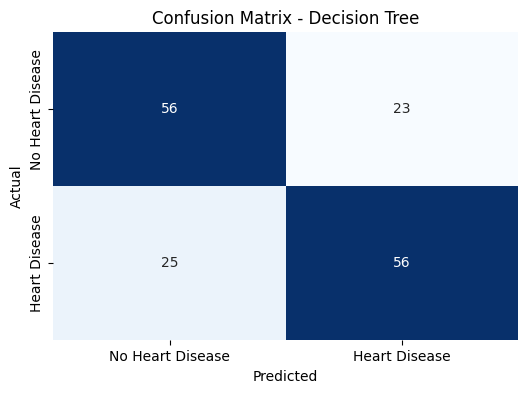

Accuracy: 0.7000
Precision: 0.7089
Recall: 0.6914
F1-Score: 0.7000

--- Random Forest Evaluation ---

Confusion Matrix for Random Forest:
[[61 18]
 [15 66]]


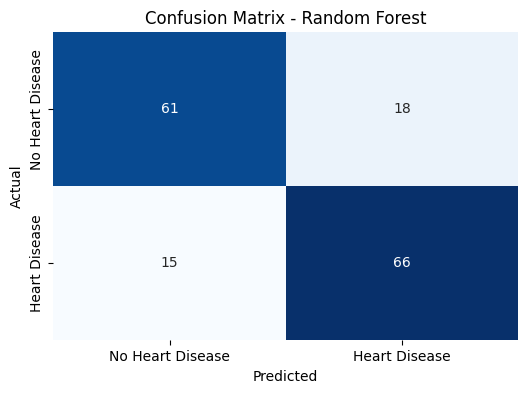

Accuracy: 0.7937
Precision: 0.7857
Recall: 0.8148
F1-Score: 0.8000

--- Gradient Boosting Evaluation ---

Confusion Matrix for Gradient Boosting:
[[61 18]
 [19 62]]


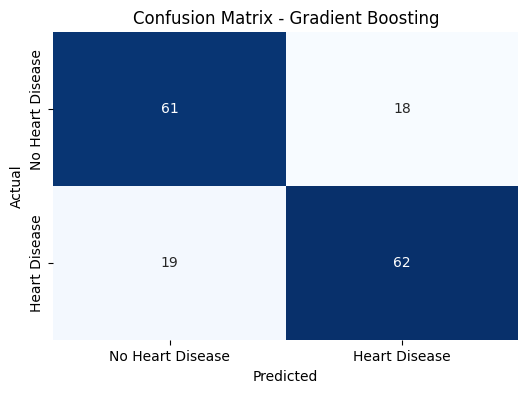

Accuracy: 0.7688
Precision: 0.7750
Recall: 0.7654
F1-Score: 0.7702


In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    print(f"\n--- {model_name} Evaluation ---")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"\nConfusion Matrix for {model_name}:\n{cm}")

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No Heart Disease', 'Heart Disease'],
                yticklabels=['No Heart Disease', 'Heart Disease'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1_score': f1}

print("Re-training models for evaluation to ensure they are defined...")
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train, y_train)

gb_classifier = GradientBoostingClassifier(random_state=42)
gb_classifier.fit(X_train, y_train)
print("Models re-trained for evaluation.")

# Evaluate all trained models
dt_metrics = evaluate_model(dt_classifier, X_test, y_test, "Decision Tree")
rf_metrics = evaluate_model(rf_classifier, X_test, y_test, "Random Forest")
gb_metrics = evaluate_model(gb_classifier, X_test, y_test, "Gradient Boosting")

### Model Performance Comparison and Justification

Based on the evaluation metrics (Precision, Recall, F1-score, and Accuracy) on the test set, we can compare the performance of the three models:

**Decision Tree Classifier:**
- Accuracy: 0.7000
- Precision: 0.7089
- Recall: 0.6914
- F1-Score: 0.7000

**Random Forest Classifier:**
- Accuracy: 0.7937
- Precision: 0.7857
- Recall: 0.8148
- F1-Score: 0.8000

**Gradient Boosting Classifier:**
- Accuracy: 0.7688
- Precision: 0.7750
- Recall: 0.7654
- F1-Score: 0.7702

**Conclusion:**

Considering the F1-score, which is a harmonic mean of precision and recall and provides a good balance between the two, the Random Forest Classifier generally performs best. It achieves a 0.8000 F1-score, which is higher than the Decision Tree's 0.7000 and Gradient Boosting's 0.7702.

Furthermore, Random Forest also shows a strong balance in both precision and recall, indicating it is good at identifying positive cases (heart disease) without making too many false positive predictions.

## 6. Hyperparameter Tuning


--- Hyperparameter Tuning for Random Forest Classifier ---
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters found: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 300}
Best F1-score on validation set: 0.8217

--- Tuned Random Forest Model Evaluation ---

--- Tuned Random Forest Evaluation ---

Confusion Matrix for Tuned Random Forest:
[[60 19]
 [16 65]]


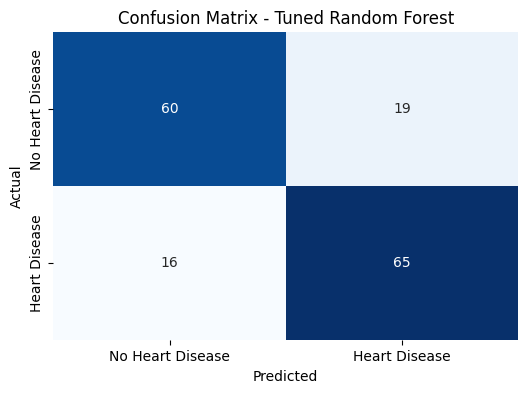

Accuracy: 0.7812
Precision: 0.7738
Recall: 0.8025
F1-Score: 0.7879

--- Comparison with Untuned Random Forest ---
Untuned Random Forest F1-score: 0.8000
Tuned Random Forest F1-score: 0.7879
Hyperparameter tuning slightly decreased or did not improve the Random Forest model's F1-score.


In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

print("\n--- Hyperparameter Tuning for Random Forest Classifier ---")

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)


grid_search.fit(X_train, y_train)

print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best F1-score on validation set: {grid_search.best_score_:.4f}")


best_rf_model = grid_search.best_estimator_

print("\n--- Tuned Random Forest Model Evaluation ---")
tuned_rf_metrics = evaluate_model(best_rf_model, X_test, y_test, "Tuned Random Forest")

print("\n--- Comparison with Untuned Random Forest ---")
print(f"Untuned Random Forest F1-score: {rf_metrics['f1_score']:.4f}")
print(f"Tuned Random Forest F1-score: {tuned_rf_metrics['f1_score']:.4f}")

if tuned_rf_metrics['f1_score'] > rf_metrics['f1_score']:
    print("Hyperparameter tuning improved the Random Forest model's F1-score.")
elif tuned_rf_metrics['f1_score'] < rf_metrics['f1_score']:
    print("Hyperparameter tuning slightly decreased or did not improve the Random Forest model's F1-score.")
else:
    print("Hyperparameter tuning resulted in similar F1-score for the Random Forest model.")